# LeetCode #271: Encode and Decode Strings

https://leetcode.com/problems/encode-and-decode-strings/

## Comparison of Approaches
| Approach | Time | Space |
|---|---|---|
| Length-Prefixed Encoding ★ | O(n) | O(n) |
| Escaped Delimiter | O(n) | O(n) |

## Understanding the Methods
### Length-Prefixed Encoding (Optimal)
Encode each string as its length followed by a delimiter (e.g., '#') then the string itself. For example, "abc" becomes "3#abc". Decoding reads the length, skips the delimiter, then extracts exactly that many characters. This handles any character including the delimiter itself since the length is authoritative.

### Escaped Delimiter
Choose a delimiter and escape any occurrence of it within the strings. More complex and error-prone compared to length-prefixed encoding.

## Solutions

### C#

In [ ]:
public class Codec {
    public string encode(IList<string> strs) {
        var sb = new System.Text.StringBuilder();
        foreach (var s in strs) {
            sb.Append(s.Length).Append('#').Append(s);
        }
        return sb.ToString();
    }

    public IList<string> decode(string s) {
        var result = new List<string>();
        int i = 0;
        while (i < s.Length) {
            int j = s.IndexOf('#', i);
            int len = int.Parse(s.Substring(i, j - i));
            result.Add(s.Substring(j + 1, len));
            i = j + 1 + len;
        }
        return result;
    }
}

### Python

In [ ]:
class Codec:
    def encode(self, strs: list[str]) -> str:
        return ''.join(f'{len(s)}#{s}' for s in strs)

    def decode(self, s: str) -> list[str]:
        result = []
        i = 0
        while i < len(s):
            j = s.index('#', i)
            length = int(s[i:j])
            result.append(s[j + 1:j + 1 + length])
            i = j + 1 + length
        return result

### Go

In [ ]:
import (
    "fmt"
    "strconv"
    "strings"
)

type Codec struct{}

func (c *Codec) Encode(strs []string) string {
    var sb strings.Builder
    for _, s := range strs {
        fmt.Fprintf(&sb, "%d#%s", len(s), s)
    }
    return sb.String()
}

func (c *Codec) Decode(s string) []string {
    result := []string{}
    i := 0
    for i < len(s) {
        j := strings.Index(s[i:], "#") + i
        length, _ := strconv.Atoi(s[i:j])
        result = append(result, s[j+1:j+1+length])
        i = j + 1 + length
    }
    return result
}

### Rust

In [ ]:
struct Codec;

impl Codec {
    fn new() -> Self { Codec }

    fn encode(&self, strs: Vec<String>) -> String {
        let mut result = String::new();
        for s in &strs {
            result.push_str(&format!("{}#{}", s.len(), s));
        }
        result
    }

    fn decode(&self, s: String) -> Vec<String> {
        let mut result = Vec::new();
        let mut i = 0;
        let bytes = s.as_bytes();
        while i < bytes.len() {
            let j = s[i..].find('#').unwrap() + i;
            let len: usize = s[i..j].parse().unwrap();
            result.push(s[j + 1..j + 1 + len].to_string());
            i = j + 1 + len;
        }
        result
    }
}

## Example Scenarios

1. **Common Case**  
   **Input:** `["Hello","World"]`  
   Encoded: `"5#Hello5#World"`. Decoder reads length 5, extracts `"Hello"`, then length 5, extracts `"World"`.

2. **Slightly Complex**  
   **Input:** `["we","say",":","yes","!#@"]`  
   Encoded: `"2#we3#say1#:3#yes3#!#@"`. The `#` inside `"!#@"` is not confused with delimiters because lengths are precise.

3. **Edge Case: Time Factor**  
   **Input:** $200$ strings each of length $200$, total $n = 40000$ characters.  
   Encoding and decoding each scan all characters once: $O(n)$ time.

4. **Edge Case: Space Factor**  
   **Input:** `["","",""]`  
   Three empty strings. Encoded: `"0#0#0#"`. Each length is 0 so nothing is extracted after `#`. Minimal space.

5. **Almost-Impossible but Plausible**  
   **Input:** `["999#aaaa"]`  
   Contains digits and `#` that look like a length prefix. Encoded: `"8#999#aaaa"`. Decoder reads length 8, grabs exactly 8 chars. No ambiguity.

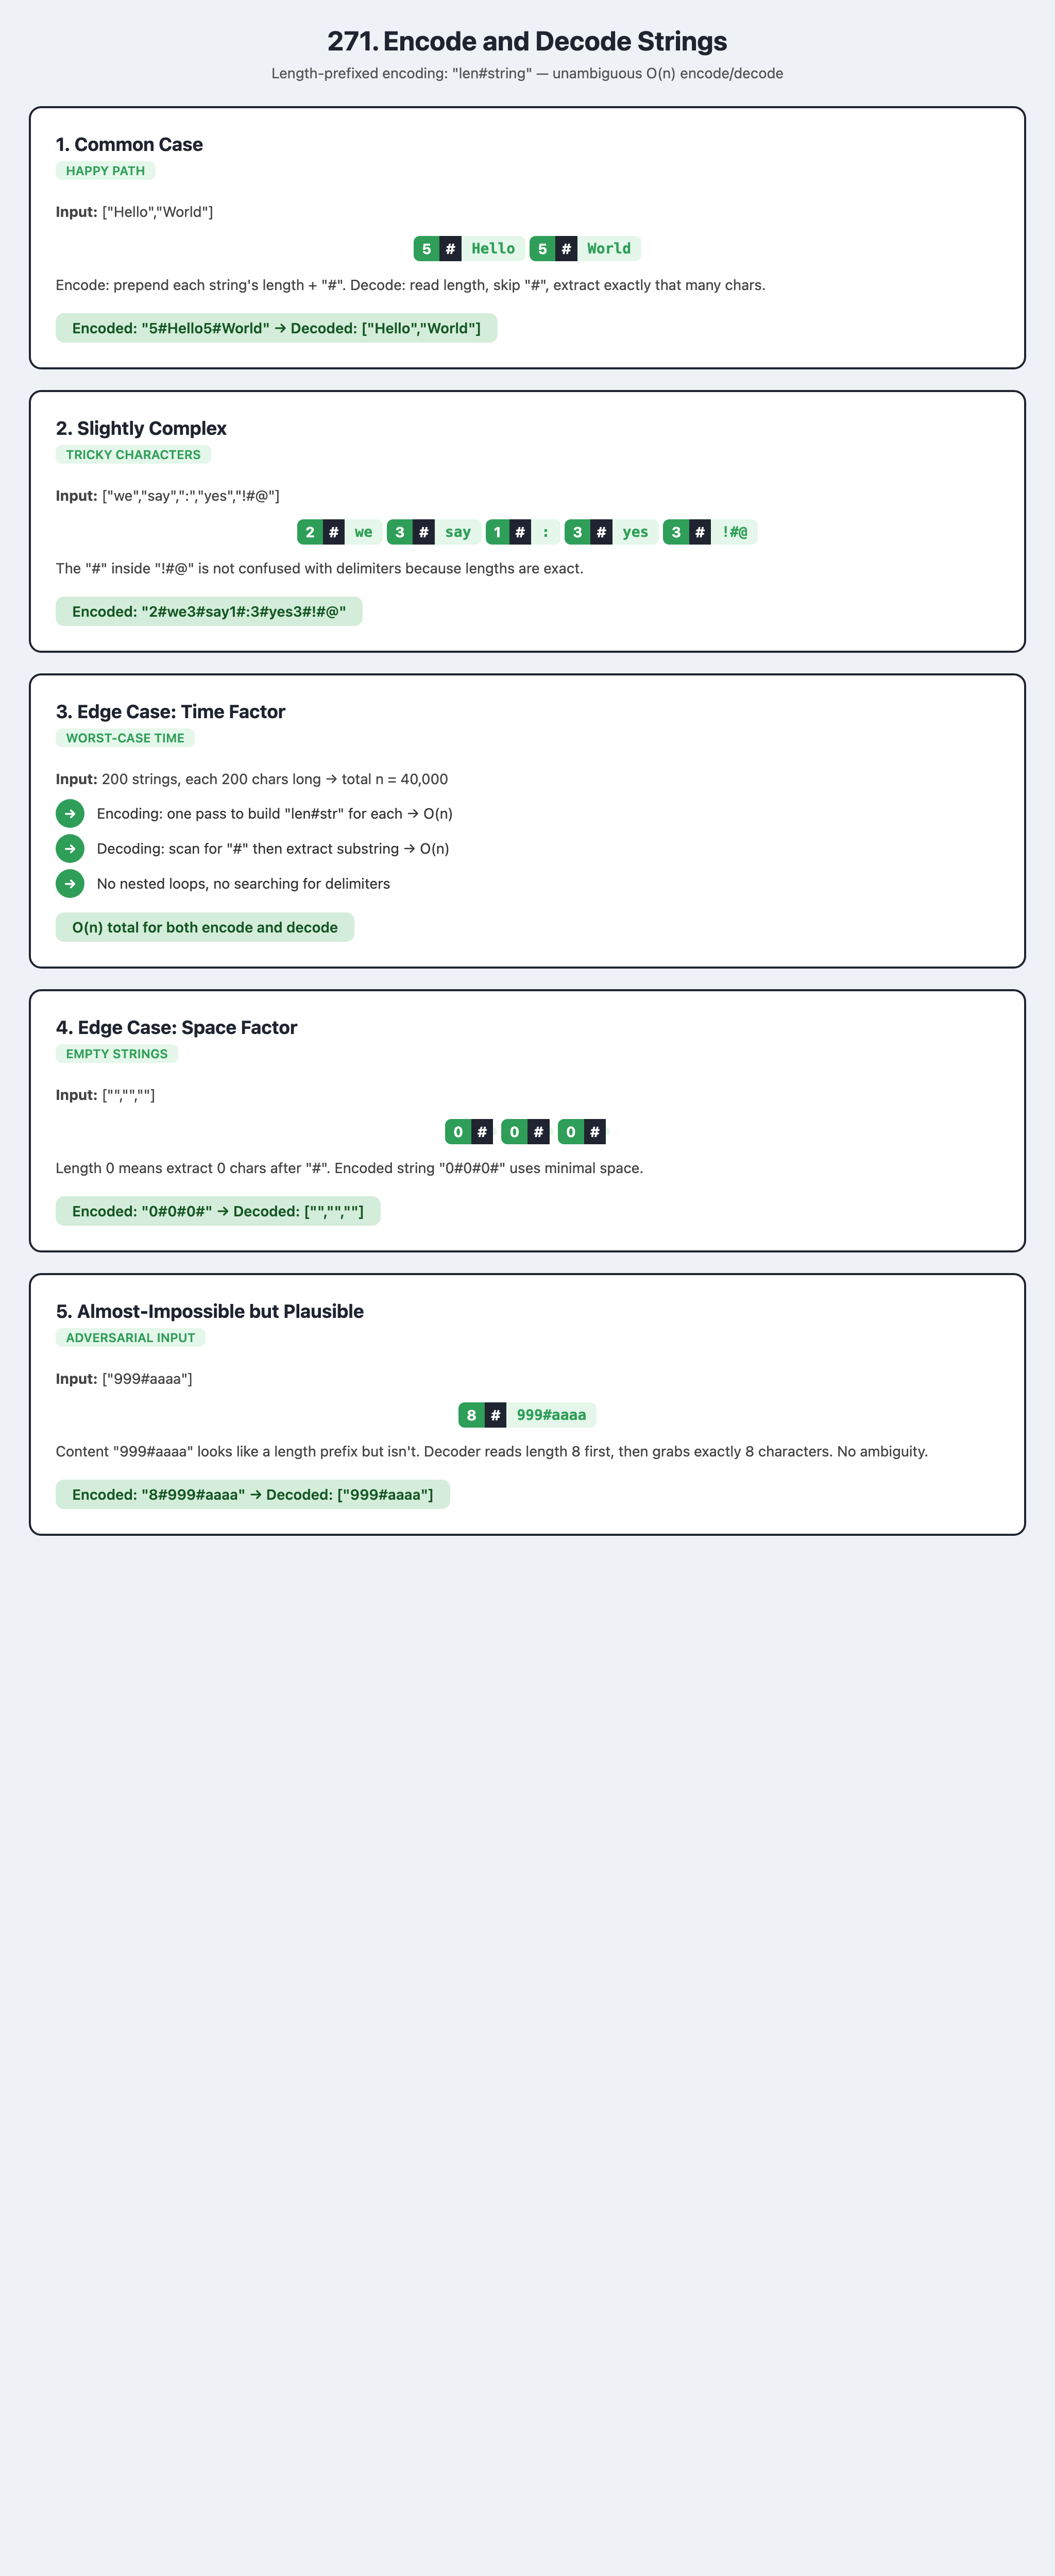